## Missing Values
Missing values occurs in dataset when some of the informations is not stored for a variable
There are 3 mechanisms

# Types of Missing Data

## 1. Missing Completely at Random (MCAR)
- **Definition:** The missingness is completely independent of both observed and unobserved data.
- **Impact:** No bias introduced; missing values are purely random.
- **Example:** A sensor randomly fails to record a value due to a power glitch.

---

## 2. Missing at Random (MAR)
- **Definition:** The missingness is related to **observed variables**, but not to the actual missing value itself.
- **Impact:** Can be handled using statistical methods (e.g., multiple imputation) if the observed variables are included in the model.
- **Example:** Older patients are less likely to report income, but their **age** is recorded. The probability of missingness depends on age (observed), not on income value itself.

---

## 3. Missing Not at Random (MNAR)
- **Definition:** The missingness is related to the **value of the missing data itself** (unobserved).
- **Impact:** Introduces bias that cannot be corrected without making strong assumptions or collecting more data.
- **Example:** People with higher incomes are less likely to disclose their income. Missingness depends directly on the unreported income value.

---

# Key Differences
- **MCAR:** Missingness is unrelated to data (observed or unobserved). → Safest assumption.
- **MAR:** Missingness depends only on observed data. → Manageable with modeling.
- **MNAR:** Missingness depends on the missing value itself. → Most problematic, needs special handling.


## Examples

In [ ]:
import seaborn as sns
import pandas as pd

In [28]:
df = pd.read_csv("/Users/sahilnagpal/Library/Application Support/JetBrains/DataSpell2025.2/projects/workspace/data/titanic.csv")

In [37]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Age_mean,age_median
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,22.0,22.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,38.0,38.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,26.0,26.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,35.0,35.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,35.0,35.0


In [29]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [31]:
## Check missing values
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [30]:
## Delete the rows or data point to handle missing values

df.shape

(891, 15)

In [ ]:
df.dropna().shape

In [ ]:
## Column wise deletion
df.dropna(axis=1)

## Imputation Missing Values
### 1- Mean Value Imputation

<AxesSubplot:xlabel='age', ylabel='Count'>

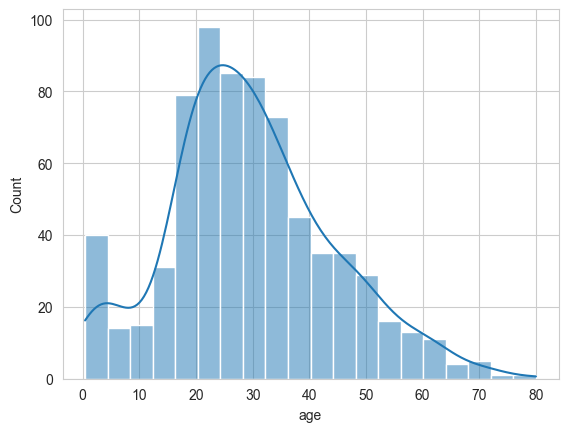

In [32]:
sns.histplot(df['age'],kde=True)

In [33]:
df['Age_mean']=df['age'].fillna(df['age'].mean())

In [34]:
df[['Age_mean','age']]

,Age_mean,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


In [ ]:
## MEan Imputation Works Well when we have normally distributed data

### 2. Median Value Imputation- If we have outliers in the dataset

In [35]:
df['age_median']=df['age'].fillna(df['age'].median())

In [36]:
df[['age_median','Age_mean','age']]

,age_median,Age_mean,age
0,22.0,22.000000,22.0
1,38.0,38.000000,38.0
2,26.0,26.000000,26.0
3,35.0,35.000000,35.0
4,35.0,35.000000,35.0
...,...,...,...
886,27.0,27.000000,27.0
887,19.0,19.000000,19.0
888,28.0,29.699118,NaN
889,26.0,26.000000,26.0


### 3. Mode Imputation Technqiue--Categorical values

In [ ]:
number = [1,2,234,45,3,4,6,6,7,6,9,0] # mode --> 6

In [38]:
df[df['embarked'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Age_mean,age_median
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0


In [41]:
df['embarked'].value_counts() # groups column --> count (unique count)

# if null > 60-100% --> no mode
# if null < 0-50% --> mode


# S --> 20
# C --> 18
# Q --> 12

S    644
C    168
Q     77
Name: embarked, dtype: int64

In [42]:
mode_value=df[df['embarked'].notna()]['embarked'].mode()[0]
mode_value

'S'

In [ ]:
df['embarked'].value_counts()

In [43]:
df['embarked_mode']=df['embarked'].fillna(mode_value)

In [44]:
df[['embarked_mode','embarked']]

,embarked_mode,embarked
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C


In [45]:
df['embarked_mode'].isnull().sum()

0

In [46]:
df['embarked'].isnull().sum()

2

### Coding Session

📝 Question 1 — Fill Missing Values with Mean

In [ ]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'Student': ['A', 'B', 'C', 'D', 'E'],
    'Maths': [78, np.nan, 65, np.nan, 90],
    'Science': [85, 80, np.nan, 88, 92]
})

## Task:
1. Fill missing values in Maths with the mean of Maths column.
2. Fill missing values in Science with the median of Science column.
3. Print the updated DataFrame.

📝 Question 2 — Biggest Single Number

#### A single number is a number that appeared only once in the MyNumbers table.
#### Find the largest single number. If there is no single number, report null.

In [ ]:
data = [[8], [8], [3], [3], [1], [4], [5], [6]]
my_numbers = pd.DataFrame(data, columns=['num']).astype({'num':'Int64'})
# my_numbers --> 6

In [51]:
my_numbers.drop_duplicates(keep = False).max() # last, first, false

num    6
dtype: int64